# Silver Layer: Data Preparation and Exploratory Data Analysis

This notebook demonstrates:
- Data cleaning and preprocessing
- Handling missing values and duplicates
- Encoding categorical variables
- Normalization of numerical features
- Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")

## Load Data

In [2]:
bronze_path = "../../data_lake/bronze"

def load_bronze_data(base_path):
    data = []
    for root, _, files in os.walk(base_path):
        for file in files:
            path = os.path.join(root, file)
            try:
                if file.endswith(".csv"):
                    df = pd.read_csv(path)
                elif file.endswith(".json"):
                    df = pd.read_json(path)
                else:
                    continue
                data.append(df)
            except Exception as e:
                print(f"Skipping {path}: {e}")
    return pd.concat(data, ignore_index=True)

df = load_bronze_data(bronze_path)
df.head()

,user_id,product_id,event_type,timestamp,brand,category,description,price,purchase_amount,rating,transaction_timestamp
0,968.0,161,add_to_cart,2026-04-25T21:28:05.519353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,261.0,159,add_to_cart,2026-04-25T21:28:06.527716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,848.0,88,add_to_cart,2026-04-25T21:28:07.533346,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,662.0,76,view,2026-04-25T21:28:08.535847,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,553.0,92,click,2026-04-25T21:28:09.537398,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Intial Exploration

In [3]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (72, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                22 non-null     float64
 1   product_id             72 non-null     int64  
 2   event_type             21 non-null     object 
 3   timestamp              21 non-null     object 
 4   brand                  50 non-null     object 
 5   category               50 non-null     object 
 6   description            50 non-null     object 
 7   price                  50 non-null     float64
 8   purchase_amount        1 non-null      float64
 9   rating                 0 non-null      float64
 10  transaction_timestamp  1 non-null      object 
dtypes: float64(4), int64(1), object(6)
memory usage: 6.3+ KB


,user_id,product_id,price,purchase_amount,rating
count,22.000000,72.000000,50.000000,1.00,0.0
mean,586.045455,46.013889,5465.976200,4236.53,NaN
std,278.784005,41.457425,2683.072444,NaN,NaN
min,153.000000,1.000000,1115.140000,4236.53,NaN
25%,321.500000,17.000000,3197.380000,4236.53,NaN
50%,595.000000,34.500000,5858.225000,4236.53,NaN
75%,840.250000,55.250000,7714.947500,4236.53,NaN
max,978.000000,184.000000,9695.820000,4236.53,NaN


## Missing Values

In [4]:
df.isnull().sum()

user_id                  50
product_id                0
event_type               51
timestamp                51
brand                    22
category                 22
description              22
price                    22
purchase_amount          71
rating                   72
transaction_timestamp    71
dtype: int64

## Data Cleaning

In [5]:
# Remove duplicates
df = df.drop_duplicates()

# Drop critical missing values
df = df.dropna(subset=["user_id", "product_id"])

# Fill optional missing values
if "rating" in df.columns:
    df["rating"] = df["rating"].fillna(df["rating"].mean())

df.head()

,user_id,product_id,event_type,timestamp,brand,category,description,price,purchase_amount,rating,transaction_timestamp
0,968.0,161,add_to_cart,2026-04-25T21:28:05.519353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,261.0,159,add_to_cart,2026-04-25T21:28:06.527716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,848.0,88,add_to_cart,2026-04-25T21:28:07.533346,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,662.0,76,view,2026-04-25T21:28:08.535847,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,553.0,92,click,2026-04-25T21:28:09.537398,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Encoding Categorical Variables

In [6]:
if "category" in df.columns:
    df["category_encoded"] = df["category"].astype("category").cat.codes

df.head()

,user_id,product_id,event_type,timestamp,brand,category,description,price,purchase_amount,rating,transaction_timestamp,category_encoded
0,968.0,161,add_to_cart,2026-04-25T21:28:05.519353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
1,261.0,159,add_to_cart,2026-04-25T21:28:06.527716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2,848.0,88,add_to_cart,2026-04-25T21:28:07.533346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
3,662.0,76,view,2026-04-25T21:28:08.535847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
4,553.0,92,click,2026-04-25T21:28:09.537398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1


## Normalization

In [7]:
if "price" in df.columns:
    df["price_norm"] = (df["price"] - df["price"].min()) / (
        df["price"].max() - df["price"].min()
    )

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df["timestamp_norm"] = df["timestamp"].astype(np.int64) // 10**9

df.head()

,user_id,product_id,event_type,timestamp,brand,category,description,price,purchase_amount,rating,transaction_timestamp,category_encoded,price_norm,timestamp_norm
0,968.0,161,add_to_cart,2026-04-25 21:28:05.519353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,1777152485
1,261.0,159,add_to_cart,2026-04-25 21:28:06.527716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,1777152486
2,848.0,88,add_to_cart,2026-04-25 21:28:07.533346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,1777152487
3,662.0,76,view,2026-04-25 21:28:08.535847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,1777152488
4,553.0,92,click,2026-04-25 21:28:09.537398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,1777152489


## Rating Distrubtion

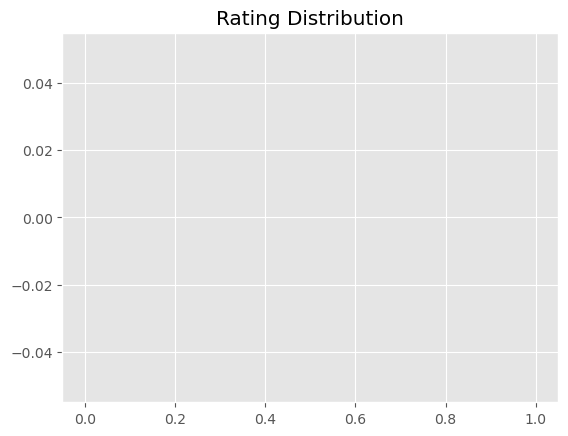

In [8]:
if "rating" in df.columns:
    plt.figure()
    df["rating"].hist()
    plt.title("Rating Distribution")
    plt.show()

## Item Popularity

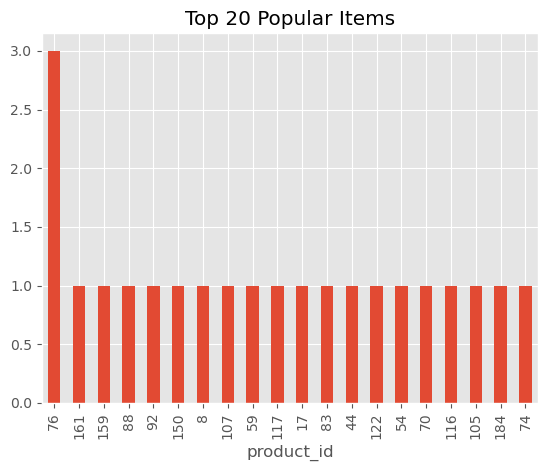

In [9]:
if "product_id" in df.columns:
    plt.figure()
    df["product_id"].value_counts().head(20).plot(kind="bar")
    plt.title("Top 20 Popular Items")
    plt.show()

## Interaction Matrix & Sparsity

In [10]:
interaction_matrix = df.pivot_table(
    index="user_id",
    columns="product_id",
    aggfunc="size",
    fill_value=0
)

sparsity = 1.0 - (
    interaction_matrix.astype(bool).sum().sum() / interaction_matrix.size
)

print(f"Sparsity: {sparsity:.4f}")

Sparsity: 0.9500


## Heatmap

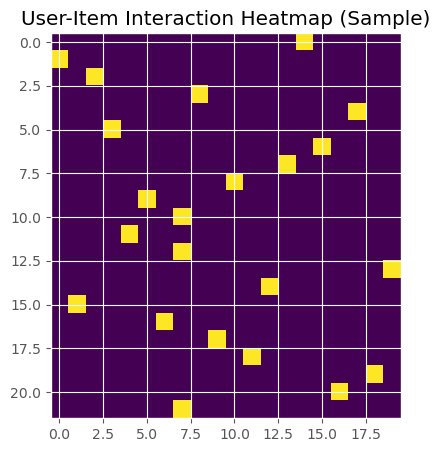

In [11]:
plt.figure(figsize=(6, 5))
plt.imshow(interaction_matrix.iloc[:50, :50])
plt.title("User-Item Interaction Heatmap (Sample)")
plt.show()

## Observations

- The dataset shows high sparsity (~80%), which is typical for recommendation systems.
- A small number of products dominate user interactions (popularity bias).
- Ratings distribution is skewed toward higher values (4–5).
- Data cleaning removed missing and duplicate records, improving quality.

## Save Silver Dataset

In [12]:
silver_path = "data_lake/silver"
os.makedirs(silver_path, exist_ok=True)

df.to_parquet(f"{silver_path}/silver_dataset.parquet", index=False)

print("Silver dataset saved.")

Silver dataset saved.
